In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
directories_ciss = ["Worn_tool_no1_pattern1/CISSRawData_LogFiles", "Worn_tool_no2_pattern2/CISSRawData_LogFiles", 
               "Worn_tool_no3_pattern3/CISSRawData_LogFiles", "Good_tool_no1_pattern4/CISSRawData_LogFiles", 
               "Good_tool_no2_pattern5/CISSRawData_LogFiles"]
directories_registry = ["Worn_tool_no1_pattern1", "Worn_tool_no2_pattern2", "Worn_tool_no3_pattern3", 
                        "Good_tool_no1_pattern4", "Good_tool_no2_pattern5"]

In [3]:
def get_ciss_raw(directory):
    dataframes = []
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path, skiprows=8, encoding='Windows-1252')
            df = df.iloc[:-1]  # Remove the last row
            df.rename(columns={"Unix TimeStamp (ms)": "TimeStamp", "Data / x_axis": "x_axis"}, inplace=True)
            df["TimeStamp"] = pd.to_numeric(df["TimeStamp"]).astype(float)
            df.drop(columns=["Measurement Type"], inplace=True)
            if directory.startswith("Worn"):
                df["Label"] = 1              # Initialize worn tool with the value 1
            if directory.startswith("Good"):
                df["Label"] = 0              # Initialize good tool with the value 0
            dataframes.append(df)
    df = pd.concat(dataframes)
    return df

In [4]:
def get_registry_record(directory):
    dataframes = []
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path)
            df.rename(columns={"Unnamed: 0": "TimeStamp"}, inplace=True)
            df["TimeStamp"] = df["TimeStamp"].astype(str).str.replace(".", "", regex=False).str[:13]
            df["TimeStamp"] = pd.to_numeric(df["TimeStamp"]).astype(float)
            df.drop(columns=["WinPCNCRunning", "CurrentJobProgress", "CurrentJobTimeMin", "CurrentJobTimeSec", "CurrentJobCommandNo", "CurrentSpdOvr", "State"], inplace=True)
            dataframes.append(df)
    df = pd.concat(dataframes)
    return df

In [5]:
dataframes_ciss = []
for directory in directories_ciss:
    dataframes_ciss.append(get_ciss_raw(directory))

In [6]:
dataframes_registry = []
for directory in directories_registry:
    dataframes_registry.append(get_registry_record(directory))

In [7]:
dataframe_ciss = pd.concat(dataframes_ciss)
dataframe_ciss = dataframe_ciss.sort_values("TimeStamp", ascending=True)
dataframe_registry = pd.concat(dataframes_registry)
dataframe_registry = dataframe_registry.sort_values("TimeStamp", ascending=True)

In [8]:
dataframe_all = pd.merge_asof(dataframe_ciss, dataframe_registry, on="TimeStamp", direction="nearest")

In [9]:
peak_threshold = dataframe_all["Pos_Z"].max()
dataframe_all = dataframe_all[dataframe_all["Pos_Z"] >= peak_threshold]

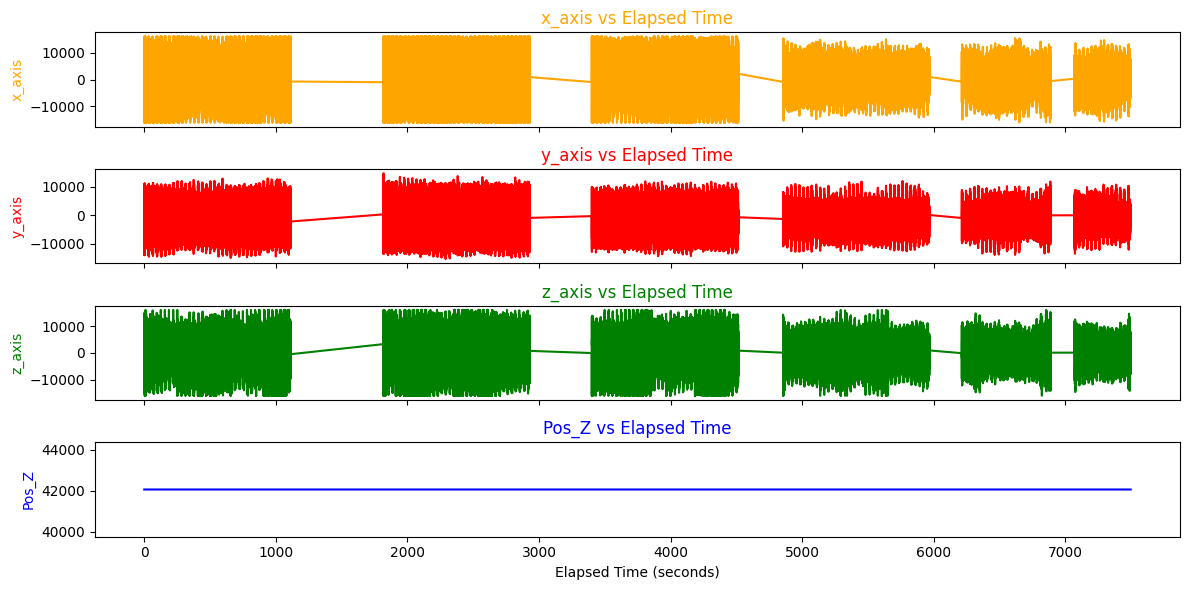

In [10]:
# Convert TimeStamp from numeric to datetime
dataframe_all['TimeStamp'] = pd.to_datetime(dataframe_all['TimeStamp'], unit='ms')

# List of columns to plot
columns_to_plot = ['x_axis', 'y_axis', 'z_axis', 'Pos_Z']

# Calculate the elapsed time since the recording started
dataframe_all['Elapsed_Time'] = (dataframe_all['TimeStamp'] - dataframe_all['TimeStamp'].iloc[0]).dt.total_seconds()

# Plot the data with the elapsed time
fig, axes = plt.subplots(len(columns_to_plot), 1, figsize=(12, 6), sharex=True)
colors = ['orange', 'red', 'green', 'blue']

# Plot each column
for ax, col, color in zip(axes, columns_to_plot, colors):
    ax.plot(dataframe_all['Elapsed_Time'], dataframe_all[col], label=col, color=color)
    ax.set_title(f'{col} vs Elapsed Time', color=color)  # Optional: Title color matches line
    ax.set_ylabel(col, color=color)  # Optional: Y-axis label matches color

# Set common x-axis label
plt.xlabel('Elapsed Time (seconds)')
plt.tight_layout()
plt.show()

In [11]:
dataframe_all.drop(columns={"Pos_X", "Pos_Y", "Pos_Z"}, inplace=True)

In [12]:
dataframe_all.to_pickle("dataframe_all.pkl")

## Dataframe aufteilen

In [8]:
dataframe_all = pd.read_pickle("dataframe_all.pkl")

In [9]:
# Erstelle Subsamples von den verschlissenen Werkzeugen
df_worn = dataframe_all[dataframe_all['Label'] == 1]
df_good = dataframe_all[dataframe_all['Label'] == 0]

# Berechne die Differenz zwischen aufeinanderfolgenden Timestamps
df_worn['time_diff'] = df_worn['TimeStamp'].diff().dt.total_seconds()

# Identifiziere die Gruppen, wo time_diff > 60 Sekunden ist
df_worn['group'] = (df_worn['time_diff'] > 60).cumsum()

# Teile das DataFrame in separate DataFrames
dfs = [group for _, group in df_worn.groupby('group')]

# Entferne die Hilfsspalten aus den einzelnen DataFrames
dfs = [group.drop(columns=['time_diff', 'group']) for group in dfs]

# Speichere die DataFrames in separaten Variablen (z. B. df_1, df_2, df_3)
df_worn_1, df_worn_2, df_worn_3 = dfs[:3]  # Nimm die ersten drei DataFrames, falls mehr vorhanden sind


/tmp/ipykernel_1091/1524485173.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_worn['time_diff'] = df_worn['TimeStamp'].diff().dt.total_seconds()
/tmp/ipykernel_1091/1524485173.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_worn['group'] = (df_worn['time_diff'] > 60).cumsum()


In [10]:
# Berechne die Differenz zwischen aufeinanderfolgenden Timestamps
df_good['time_diff'] = df_good['TimeStamp'].diff().dt.total_seconds()

# Identifiziere die Gruppen, wo time_diff > 60 Sekunden ist
df_good['group'] = (df_good['time_diff'] > 60).cumsum()

# Teile das DataFrame in separate DataFrames
dfs = [group for _, group in df_good.groupby('group')]

# Entferne die Hilfsspalten aus den einzelnen DataFrames
dfs = [group.drop(columns=['time_diff', 'group']) for group in dfs]

# Speichere die DataFrames in separaten Variablen (z. B. df_1, df_2, df_3)
df_good_1, df_good_2, df_good_3 = dfs[:3]  # Nimm die ersten drei DataFrames, falls mehr vorhanden sind

/tmp/ipykernel_1091/506017049.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_good['time_diff'] = df_good['TimeStamp'].diff().dt.total_seconds()
/tmp/ipykernel_1091/506017049.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_good['group'] = (df_good['time_diff'] > 60).cumsum()


In [11]:
# Kombiniere df2 und df3 zu einem neuen DataFrame, da sie beide zum gleichen Werkzeug gehören (Probleme im Ablauf)
df_good23 = pd.concat([df_good_2, df_good_3], ignore_index=True)

## Windowing & extracting different features from every window

In [16]:
'''
# Parameters
num_windows = 18000  # Number of desired windows
window_size = len(dataframe_all) // num_windows  # Calculate the window size dynamically
step_size = window_size  # Ensure no overlap between windows

# Create windows
windows = []
for i in range(0, len(dataframe_all), step_size):
    # Check if there's enough data left for a full window
    if i + window_size > len(dataframe_all):
        break
    
    # Extract the window data
    window_data = dataframe_all.iloc[i:i + window_size]
    
    # Calculate features
    features = {
        'x_mean': window_data['x_axis'].mean(),
        'x_std': window_data['x_axis'].std(),
        'x_sum': window_data['x_axis'].sum(),
        'x_median': window_data['x_axis'].median(),
        'y_mean': window_data['y_axis'].mean(),
        'y_std': window_data['y_axis'].std(),
        'y_sum': window_data['y_axis'].sum(),
        'y_median': window_data['y_axis'].median(),
        'z_mean': window_data['z_axis'].mean(),
        'z_std': window_data['z_axis'].std(),
        'z_sum': window_data['z_axis'].sum(),
        'z_median': window_data['z_axis'].median(),
        # Add more features as needed
    }
    
    # Assign label based on majority
    label = window_data['Label'].mode()[0]
    features['Label'] = label
    
    windows.append(features)

# Convert to DataFrame
windowed_data = pd.DataFrame(windows)
'''

"\n# Parameters\nnum_windows = 18000  # Number of desired windows\nwindow_size = len(dataframe_all) // num_windows  # Calculate the window size dynamically\nstep_size = window_size  # Ensure no overlap between windows\n\n# Create windows\nwindows = []\nfor i in range(0, len(dataframe_all), step_size):\n    # Check if there's enough data left for a full window\n    if i + window_size > len(dataframe_all):\n        break\n    \n    # Extract the window data\n    window_data = dataframe_all.iloc[i:i + window_size]\n    \n    # Calculate features\n    features = {\n        'x_mean': window_data['x_axis'].mean(),\n        'x_std': window_data['x_axis'].std(),\n        'x_sum': window_data['x_axis'].sum(),\n        'x_median': window_data['x_axis'].median(),\n        'y_mean': window_data['y_axis'].mean(),\n        'y_std': window_data['y_axis'].std(),\n        'y_sum': window_data['y_axis'].sum(),\n        'y_median': window_data['y_axis'].median(),\n        'z_mean': window_data['z_axis'].

In [43]:
## windowed_data.to_csv("windowed.csv")

In [44]:
# Sum accelerations over axis

In [ ]:
'''
plt.figure(figsize=(8, 6))
for label in windowed_data['Label'].unique():
    subset = windowed_data[windowed_data['Label'] == label]
    plt.scatter(subset['x_mean'], subset['y_mean'], label=f"Label {label}", alpha=0.5)

plt.xlabel("x_mean")
plt.ylabel("y_mean")
plt.title("2D Scatter Plot of Acceleration Data")
plt.legend()
plt.show()
'''

## Using tsfresh to extract features from Windows

In [10]:
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh import select_features

In [11]:
# Parameter
num_windows = 3600  # Anzahl der gewünschten Windows
window_size = len(df_worn_1) // num_windows  # Dynamische Berechnung der Fenstergröße
step_size = window_size  # Keine Überlappung der Windows

# Liste für zwischengespeicherte Fenster
windowed_data = []

# IDs für jedes Fenster vergeben
window_id = 0
for i in range(0, len(df_worn_1), step_size):
    # Sicherstellen, dass das Fenster vollständig ist
    if i + window_size > len(df_worn_1):
        break

    # Daten für das aktuelle Fenster extrahieren
    window_data = df_worn_1.iloc[i:i + window_size].copy()
    window_data["id"] = window_id  # Eindeutige ID für das Fenster
    windowed_data.append(window_data)
    window_id += 1

# Alle Fenster in einem DataFrame zusammenführen
windowed_df = pd.concat(windowed_data)

# Label pro Fenster basierend auf der Mehrheit zuweisen
labels = (
    windowed_df.groupby("id")["Label"]
    .agg(lambda x: x.mode()[0])  # Mehrheit bestimmen
    .reset_index()
)

# Reshape für tsfresh: Achsen in eine lange Form bringen
melted_df = windowed_df.melt(
    id_vars=["id", "Label"],  # Beibehalten von Fenster-ID und Label
    value_vars=["x_axis", "y_axis", "z_axis"],  # Spalten, die zu verarbeiten sind
    var_name="kind",  # Achsentyp (x, y, z)
    value_name="value"  # Werte der Achsen
)

# Features mit tsfresh extrahieren
features = extract_features(
    melted_df,
    column_id="id",       # Fenster-ID
    column_kind="kind",   # Achsentyp (x_axis, y_axis, z_axis)
    column_value="value", # Werte der Achsen
)

# Labels mit den Features zusammenführen
labeled_features = features.merge(labels, on="id", how="inner")

# Resultierender DataFrame mit Features und Labels
print(labeled_features)

Feature Extraction: 100%|██████████| 20/20 [20:21<00:00, 61.07s/it]  


KeyError: 'id'